In [1]:
import pandas as pd
df = pd.read_csv("SeoulBikeData.csv")
display (df.head())

,Date,Rented Bike Count,Hour,Temperature(�C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(�C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [2]:
print(df.info())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Check duplicated rows
print("\nNumber of duplicated rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(�C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(�C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [3]:
# Convert Date into datetime format
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

# Check the data type
print(df["Date"].dtype)

# Display the first few dates
print(df["Date"].head())

datetime64[us]
0   2017-12-01
1   2017-12-01
2   2017-12-01
3   2017-12-01
4   2017-12-01
Name: Date, dtype: datetime64[us]


In [4]:
print(df[["Date", "Hour"]].head())


        Date  Hour
0 2017-12-01     0
1 2017-12-01     1
2 2017-12-01     2
3 2017-12-01     3
4 2017-12-01     4


In [5]:
# Extract day of the week
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Extract month
df["Month"] = df["Date"].dt.month

# Create weekend indicator
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

# Display the new features
display(df[["Date", "DayOfWeek", "Month", "IsWeekend"]].head())

,Date,DayOfWeek,Month,IsWeekend
0,2017-12-01,4,12,0
1,2017-12-01,4,12,0
2,2017-12-01,4,12,0
3,2017-12-01,4,12,0
4,2017-12-01,4,12,0


In [6]:
categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

numerical_features = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Seasons', 'Holiday', 'Functioning Day']

Numerical features:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'DayOfWeek', 'Month', 'IsWeekend']


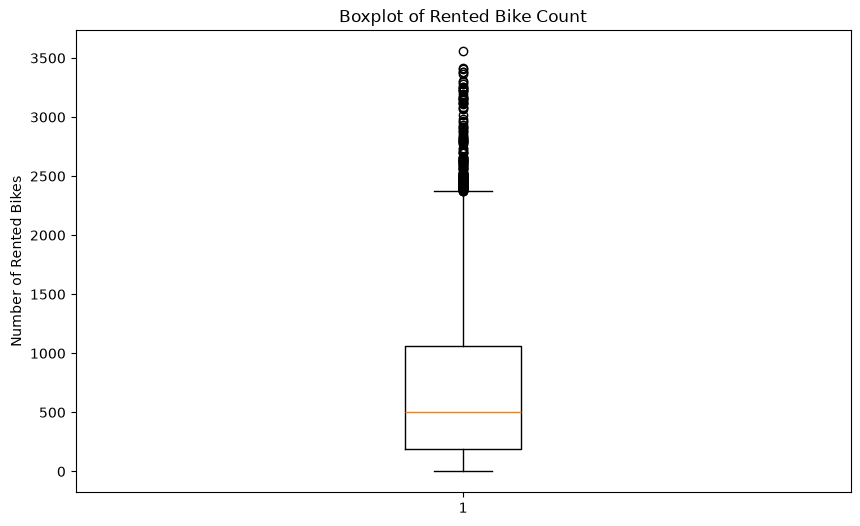

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot(df["Rented Bike Count"])

plt.title("Boxplot of Rented Bike Count")
plt.ylabel("Number of Rented Bikes")

plt.show()

In [8]:
Q1 = df["Rented Bike Count"].quantile(0.25)
Q3 = df["Rented Bike Count"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify potential outliers
outliers = df[
    (df["Rented Bike Count"] < lower_bound) |
    (df["Rented Bike Count"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 191.0
Q3: 1065.25
IQR: 874.25
Lower Bound: -1120.375
Upper Bound: 2376.625
Number of potential outliers: 158


In [9]:
# Define target variable
y = df["Rented Bike Count"]

# Define predictor variables
X = df[
    [
        "Date",
        "Rented Bike Count",
        "Hour",
        "Temperature(�C)",
        "Humidity(%)",
        "Wind speed (m/s)",
        "Visibility (10m)",
        "Dew point temperature(�C)",
        "Solar Radiation (MJ/m2)",
        "Rainfall(mm)",
        "Snowfall (cm)",
        "Seasons",
        "Holiday",
        "Functioning Day"
    ]
]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8760, 14)
y shape: (8760,)


In [10]:
# Sort the dataset chronologically
df = df.sort_values(["Date", "Hour"]).reset_index(drop=True)

# Define target
y = df["Rented Bike Count"]

# Define predictors
X = df[
    [
        "Hour",
        "Temperature(�C)",
        "Humidity(%)",
        "Wind speed (m/s)",
        "Visibility (10m)",
        "Dew point temperature(�C)",
        "Solar Radiation (MJ/m2)",
        "Rainfall(mm)",
        "Snowfall (cm)",
        "Seasons",
        "Holiday",
        "Functioning Day",
        "DayOfWeek",
        "Month",
        "IsWeekend"
    ]
]

# Calculate split point
split_index = int(len(df) * 0.8)

# Chronological train-test split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7008, 15)
Testing data: (1752, 15)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Categorical columns
categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

# Numerical columns
numerical_features = [
    "Hour",
    "Temperature(�C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(�C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("SeoulBikeData.csv")

# Convert Date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort chronologically
df = df.sort_values(["Date", "Hour"]).reset_index(drop=True)

# Feature engineering
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# Target
target = "Rented Bike Count"

# Features
features = [
    "Hour",
    "Temperature(�C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(�C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "Seasons",
    "Holiday",
    "Functioning Day",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

X = df[features]
y = df[target]

# Chronological 80/20 split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Numerical and categorical columns
numerical_features = [
    "Hour",
    "Temperature(�C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(�C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

# Preprocessing for Linear Regression
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression())
    ]
)

In [13]:
# Train Linear Regression
linear_model.fit(X_train, y_train)

print("Linear Regression training completed.")

Linear Regression training completed.


In [14]:
# Prediction
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

print("Linear Regression predictions generated.")

Linear Regression predictions generated.


In [15]:
# Evaluation function
def evaluate_model(model_name, y_train, train_pred, y_test, test_pred):

    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    return {
        "Model": model_name,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Train R²": train_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R²": test_r2
    }


linear_results = evaluate_model(
    "Linear Regression",
    y_train,
    linear_train_pred,
    y_test,
    linear_test_pred
)

print(linear_results)

{'Model': 'Linear Regression', 'Train MAE': 327.68725837811206, 'Train RMSE': np.float64(436.1765841909346), 'Train R²': 0.5524221799946154, 'Test MAE': 314.29209698314105, 'Test RMSE': np.float64(412.11695003492156), 'Test R²': 0.5485088662316202}


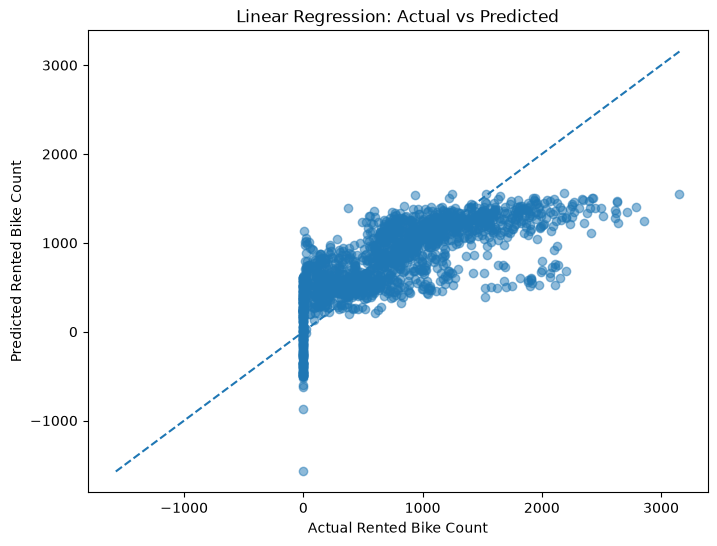

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_test_pred, alpha=0.5)

min_value = min(y_test.min(), linear_test_pred.min())
max_value = max(y_test.max(), linear_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [17]:
#5.2
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

In [18]:
tree_param_grid = {
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

tree_grid = GridSearchCV(
    tree_model,
    tree_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(tree_grid.best_params_)

Best Decision Tree parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}


In [19]:
tree_model_final = tree_grid.best_estimator_

In [20]:
tree_model_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Hour','Temperature(�C)','Humidity(%)',...,'DayOfWeek','Month', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [21]:
tree_train_pred = tree_model_final.predict(X_train)
tree_test_pred = tree_model_final.predict(X_test)

In [22]:
tree_results = evaluate_model(
    "Decision Tree Regression",
    y_train,
    tree_train_pred,
    y_test,
    tree_test_pred
)

print(tree_results)

{'Model': 'Decision Tree Regression', 'Train MAE': 114.04745157551136, 'Train RMSE': np.float64(196.7239199329075), 'Train R²': 0.9089545594624591, 'Test MAE': 260.90469539330314, 'Test RMSE': np.float64(378.3118662639208), 'Test R²': 0.6195407043600039}


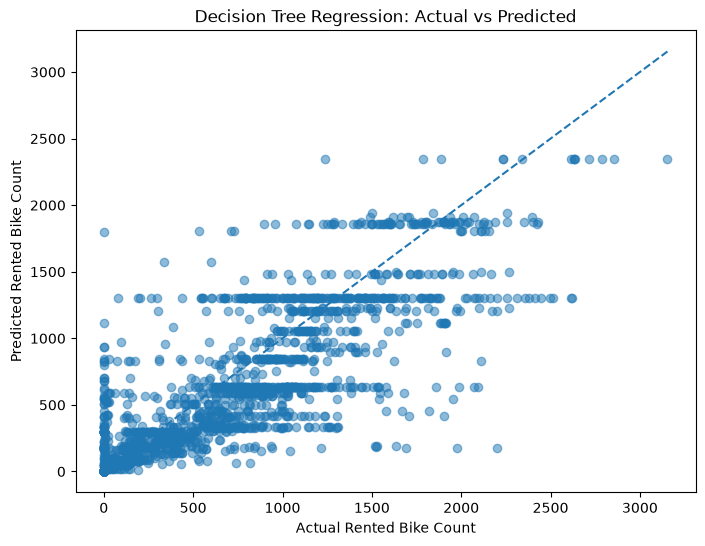

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, tree_test_pred, alpha=0.5)

min_value = min(y_test.min(), tree_test_pred.min())
max_value = max(y_test.max(), tree_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.show()

In [24]:
#5.3
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Hour','Temperature(�C)','Humidity(%)',...,'DayOfWeek','Month', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [26]:
rf_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": [1.0, "sqrt"]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)

{'model__max_depth': 20, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [27]:
rf_final = rf_model

In [28]:
rf_final.fit(X_train, y_train)

rf_train_pred = rf_final.predict(X_train)
rf_test_pred = rf_final.predict(X_test)


In [29]:
rf_results = evaluate_model(
    "Random Forest Regression",
    y_train,
    rf_train_pred,
    y_test,
    rf_test_pred
)

print(rf_results)

{'Model': 'Random Forest Regression', 'Train MAE': 34.58805507990868, 'Train RMSE': np.float64(62.69607044112542), 'Train R²': 0.9907524964678234, 'Test MAE': 220.41365867579907, 'Test RMSE': np.float64(318.73368274261344), 'Test R²': 0.7299375560456323}


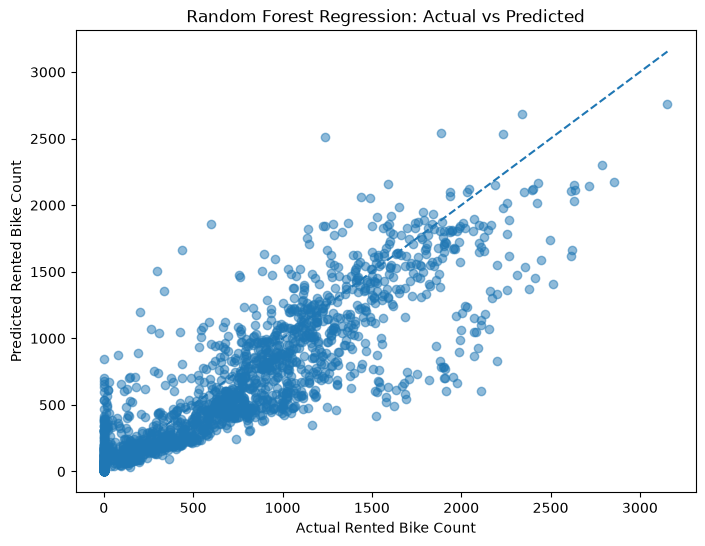

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_test_pred, alpha=0.5)

min_value = min(y_test.min(), rf_test_pred.min())
max_value = max(y_test.max(), rf_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Random Forest Regression: Actual vs Predicted")

plt.show()

In [69]:
#5.4
gb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

gb_model = Pipeline(
    steps=[
        ("preprocessor", gb_preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)



In [68]:
gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_leaf": [1, 2, 5]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

gb_final = gb_grid.best_estimator_

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}


In [73]:
gb_train_pred = gb_final.predict(X_train)
gb_test_pred = gb_final.predict(X_test)
print("Gradient Boosting training completed.")
gb_final.fit(X_train, y_train)

Gradient Boosting training completed.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Hour','Temperature(�C)','Humidity(%)',...,'DayOfWeek','Month', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [74]:
gb_train_pred = gb_final.predict(X_train)
gb_test_pred = gb_final.predict(X_test)

print("Gradient Boosting predictions generated.")

Gradient Boosting predictions generated.


In [59]:
gb_results = evaluate_model(
    "Gradient Boosting Regression",
    y_train,
    gb_train_pred,
    y_test,
    gb_test_pred
)
df_results = pd.DataFrame([gb_results])
display(df_results)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
0,Gradient Boosting Regression,73.089024,119.059117,0.966652,191.377283,271.262207,0.804392


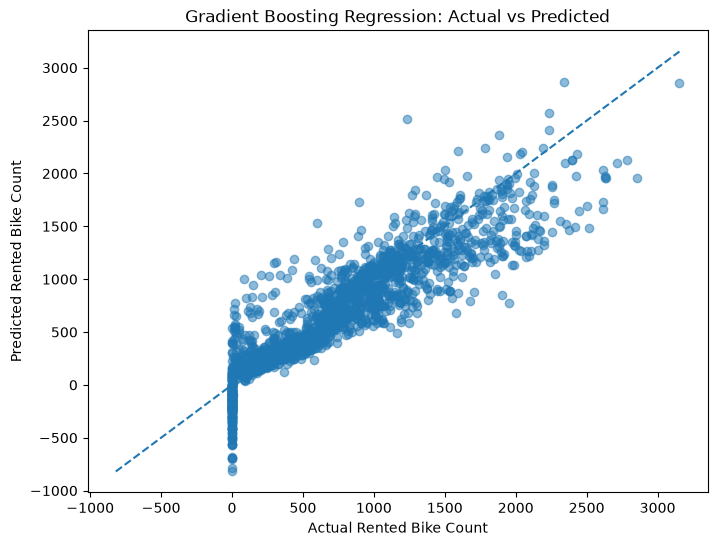

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, gb_test_pred, alpha=0.5)

min_value = min(y_test.min(), gb_test_pred.min())
max_value = max(y_test.max(), gb_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Gradient Boosting Regression: Actual vs Predicted")

plt.show()

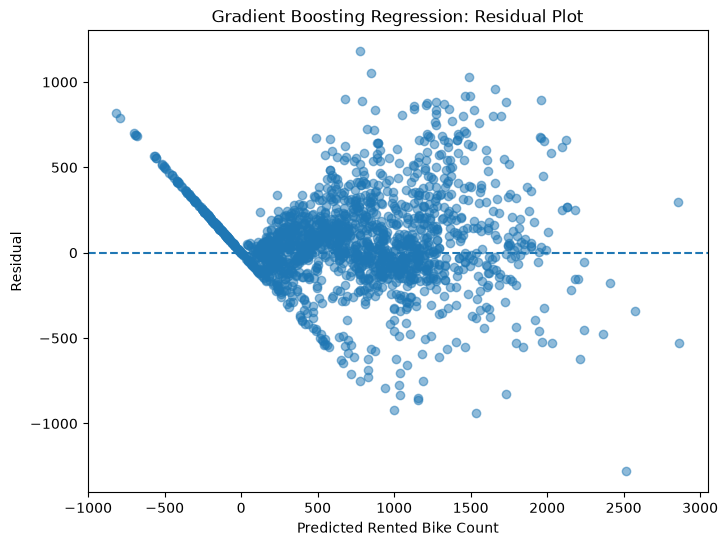

In [62]:
gb_residuals = y_test - gb_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    gb_test_pred,
    gb_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residual")
plt.title("Gradient Boosting Regression: Residual Plot")

plt.show()
